In [1]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd 

In [2]:
from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

username = "postgres"
password = quote_plus("kishan@845290")   
host = "localhost"
port = "5432"
database = "company"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# Test connection
test_query = "SELECT COUNT(*) FROM orders;"
df_test = pd.read_sql(test_query, engine)
print(df_test)

   count
0  99441


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

query1 = """
SELECT order_status, COUNT(*) AS total_orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM orders
GROUP BY order_status
ORDER BY total_orders DESC;
"""
df_status = pd.read_sql(query1, engine)
print(df_status)



  order_status  total_orders  percentage
0    delivered         96478       97.02
1      shipped          1107        1.11
2     canceled           625        0.63
3  unavailable           609        0.61
4     invoiced           314        0.32
5   processing           301        0.30
6      created             5        0.01
7     approved             2        0.00


C:\Users\HP\AppData\Local\Temp\ipykernel_9688\1009093021.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_status, x='total_orders', y='order_status', palette='viridis')


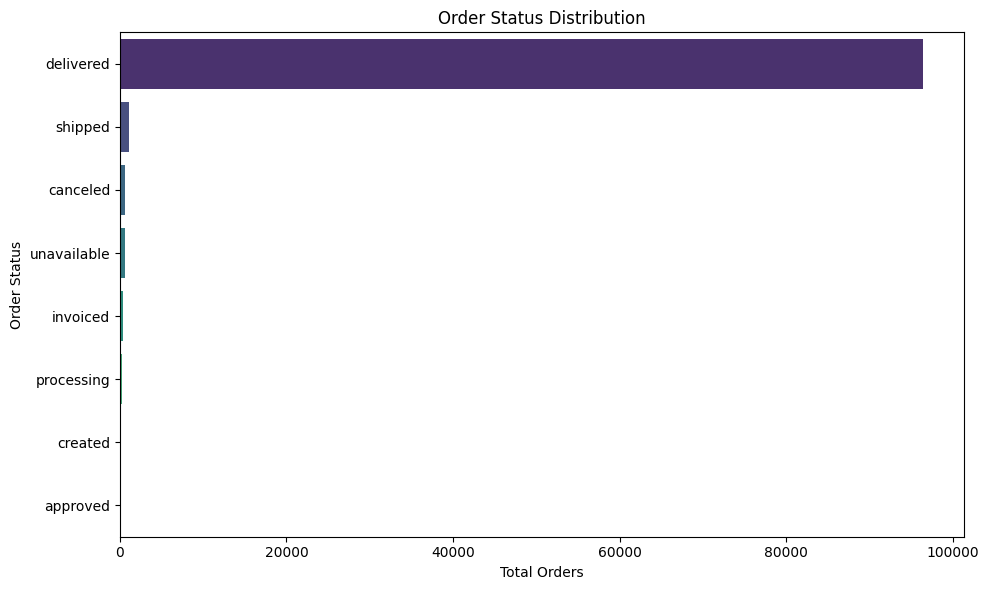

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(data=df_status, x='total_orders', y='order_status', palette='viridis')
plt.title('Order Status Distribution')
plt.xlabel('Total Orders')
plt.ylabel('Order Status')
plt.tight_layout()

plt.savefig('order_status_distribution.png', dpi=300, bbox_inches='tight')
plt.show()                                                                   

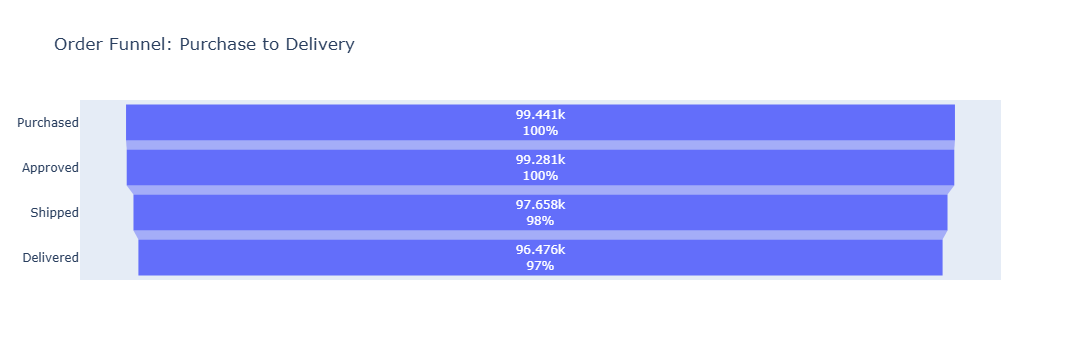

In [27]:
query2 = """
SELECT 
    COUNT(*) AS purchased,
    COUNT(order_approved_at) AS approved,
    COUNT(order_delivered_carrier_date) AS shipped,
    COUNT(order_delivered_customer_date) AS delivered
FROM orders;
"""
df_funnel = pd.read_sql(query2, engine)

stages = ['Purchased', 'Approved', 'Shipped', 'Delivered']
values = df_funnel.iloc[0].tolist()

import plotly.graph_objects as go

fig = go.Figure(go.Funnel(
    y=stages,
    x=values,
    textinfo="value+percent initial"
))
fig.update_layout(title="Order Funnel: Purchase to Delivery")
fig.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9688\4034828560.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_category, x='failure_rate_pct', y='category', palette='rocket')


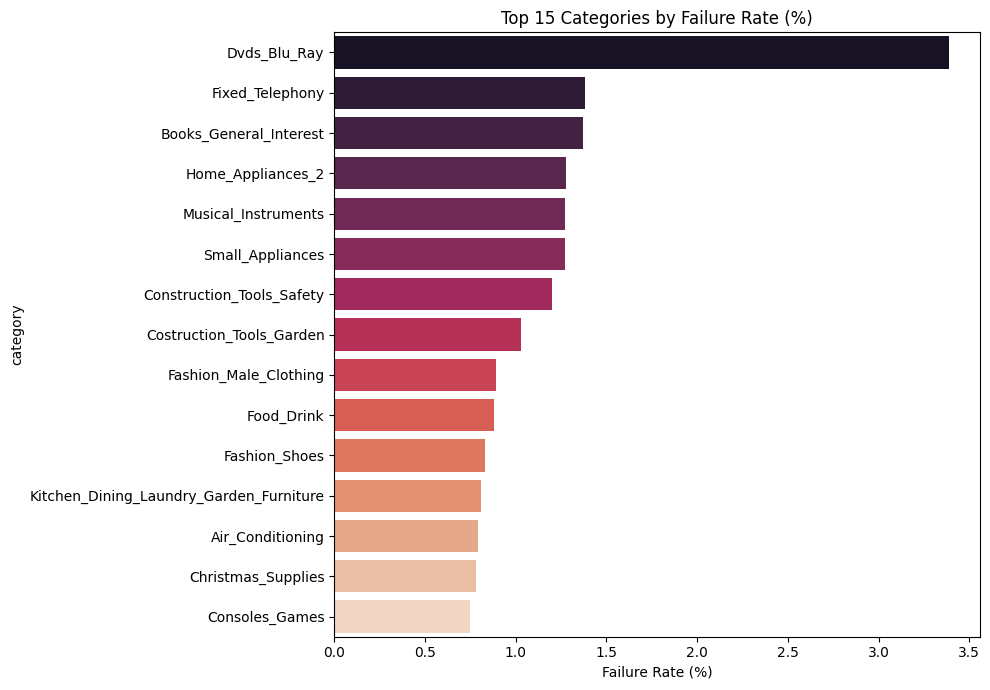

In [21]:
query3 = """
WITH category_orders AS (
    SELECT 
        pc.product_category_name_english AS category,
        o.order_id,
        o.order_status,
        o.order_approved_at,
        o.order_delivered_carrier_date
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    JOIN products p ON oi.product_id = p.product_id
    LEFT JOIN product_category pc 
        ON TRIM(LOWER(p.product_category_name)) = TRIM(LOWER(pc.product_category_name))
)
SELECT 
    category,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT CASE 
        WHEN order_status = 'unavailable' 
             OR (order_status = 'canceled' AND order_approved_at IS NOT NULL AND order_delivered_carrier_date IS NULL)
        THEN order_id 
    END) AS failed_orders,
    ROUND(
        100.0 * COUNT(DISTINCT CASE 
            WHEN order_status = 'unavailable' 
                 OR (order_status = 'canceled' AND order_approved_at IS NOT NULL AND order_delivered_carrier_date IS NULL)
            THEN order_id 
        END) / COUNT(DISTINCT order_id), 2
    ) AS failure_rate_pct
FROM category_orders
WHERE category IS NOT NULL
GROUP BY category
HAVING COUNT(DISTINCT order_id) >= 30
ORDER BY failure_rate_pct DESC
LIMIT 15;
"""
df_category = pd.read_sql(query3, engine)

plt.figure(figsize=(10,7))
sns.barplot(data=df_category, x='failure_rate_pct', y='category', palette='rocket')
plt.title('Top 15 Categories by Failure Rate (%)')
plt.xlabel('Failure Rate (%)')
plt.tight_layout()
plt.savefig('Top 15 Categories by Failure Rate.png', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_9688\3125323371.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_seller, x='failure_rate_pct', y='seller_id', palette='flare')


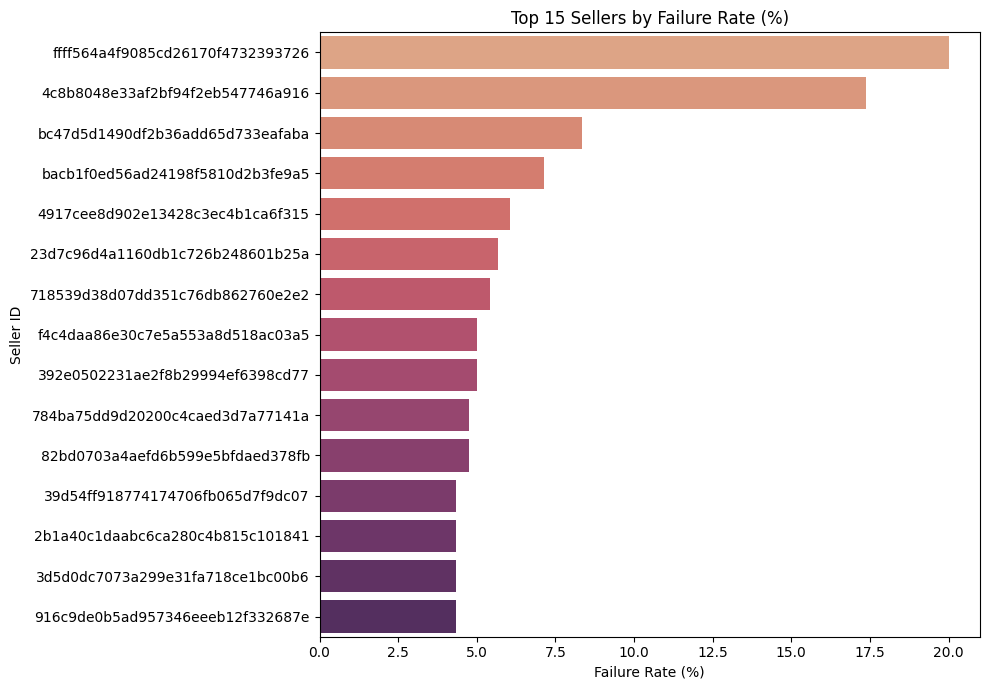

In [24]:
query4 = """
WITH seller_orders AS (
    SELECT 
        oi.seller_id,
        o.order_id,
        o.order_status,
        o.order_approved_at,
        o.order_delivered_carrier_date
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
)
SELECT 
    seller_id,
    COUNT(DISTINCT order_id) AS total_orders,
    COUNT(DISTINCT CASE 
        WHEN order_status = 'unavailable' 
             OR (order_status = 'canceled' AND order_approved_at IS NOT NULL AND order_delivered_carrier_date IS NULL)
        THEN order_id 
    END) AS failed_orders,
    ROUND(
        100.0 * COUNT(DISTINCT CASE 
            WHEN order_status = 'unavailable' 
                 OR (order_status = 'canceled' AND order_approved_at IS NOT NULL AND order_delivered_carrier_date IS NULL)
            THEN order_id 
        END) / COUNT(DISTINCT order_id), 2
    ) AS failure_rate_pct
FROM seller_orders
GROUP BY seller_id
HAVING COUNT(DISTINCT order_id) >= 20
ORDER BY failure_rate_pct DESC
LIMIT 15;
"""
df_seller = pd.read_sql(query4, engine)

plt.figure(figsize=(10,7))
sns.barplot(data=df_seller, x='failure_rate_pct', y='seller_id', palette='flare')
plt.title('Top 15 Sellers by Failure Rate (%)')
plt.xlabel('Failure Rate (%)')
plt.ylabel('Seller ID')
plt.tight_layout()
plt.savefig('Top 15 Sallers by Failure Rate.png', dpi=300, bbox_inches='tight')
plt.show()

In [7]:
import pandas as pd

summary_data = {
    "Metric": [
        "Total Orders",
        "Delivered Orders (%)",
        "Overall Drop-out Rate (%)",
        "Purchase → Approved Drop",
        "Approved → Shipped Drop",
        "Shipped → Delivered Drop",
        "Total Canceled Orders",
        "  - Canceled before approval",
        "  - Canceled after approval, before shipping",
        "  - Canceled after shipping, before delivery",
        "Total Unavailable Orders",
        "Highest Category Failure Rate",
        "Highest Seller Failure Rate",
        "Baseline Failure Rate (avg)"
    ],
    "Value": [
        99441,
        "97.02%",
        "~2.98%",
        "160 orders (0.16%)",
        "1,623 orders (1.63%)",
        "1,182 orders (1.21%)",
        625,
        "141 (22.6%)",
        "409 (65.4%)",
        "69 (11.0%)",
        609,
        "Dvds_Blu_Ray — 3.39% (small sample)",
        "Top seller — 20.00% (20x baseline)",
        "~1%"
    ],
    "Insight": [
        "Baseline for all analysis",
        "Business is largely healthy overall",
        "Small but concentrated problem",
        "Payment approval stage is healthy",
        "PRIMARY leak point in the funnel",
        "Secondary leak — logistics/delivery issue",
        "Majority happen post-approval",
        "Likely customer-driven / payment failure",
        "Likely seller-side fulfillment failure",
        "Likely courier/logistics failure",
        "Stock/seller availability issue",
        "Not a strong category-level pattern",
        "STRONG signal — specific sellers underperform",
        "Category-level variation is minor vs seller-level"
    ]
}

df_summary = pd.DataFrame(summary_data)
pd.set_option('display.max_colwidth', None)
df_summary

,Metric,Value,Insight
0,Total Orders,99441,Baseline for all analysis
1,Delivered Orders (%),97.02%,Business is largely healthy overall
2,Overall Drop-out Rate (%),~2.98%,Small but concentrated problem
3,Purchase → Approved Drop,160 orders (0.16%),Payment approval stage is healthy
4,Approved → Shipped Drop,"1,623 orders (1.63%)",PRIMARY leak point in the funnel
5,Shipped → Delivered Drop,"1,182 orders (1.21%)",Secondary leak — logistics/delivery issue
6,Total Canceled Orders,625,Majority happen post-approval
7,- Canceled before approval,141 (22.6%),Likely customer-driven / payment failure
8,"- Canceled after approval, before shipping",409 (65.4%),Likely seller-side fulfillment failure
9,"- Canceled after shipping, before delivery",69 (11.0%),Likely courier/logistics failure
